<a href="https://colab.research.google.com/github/abasovmanaf-3267/project_pandas/blob/main/notebook_ipynb_adl%C4%B1_not_defterinin_kopyas%C4%B1_Manaf_yellow_notes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
import pandas as pd
orders         = pd.read_csv('/content/drive/MyDrive/pandas =_project/instacart_orders.csv', sep=';')
products       = pd.read_csv('/content/drive/MyDrive/pandas =_project/products.csv', sep=';')
departments    = pd.read_csv('/content/drive/MyDrive/pandas =_project/departments.csv', sep=';')
aisles         = pd.read_csv('/content/drive/MyDrive/pandas =_project/aisles.csv', sep=';')
order_products = pd.read_csv('/content/drive/MyDrive/pandas =_project/order_products.csv', sep=';')


### `products` data frame

In [5]:
products.head()

,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1
4,5,Green Chile Anytime Sauce,5,13


In [6]:
products.shape

(49694, 4)

In [7]:
products.isna().sum()

,0
product_id,0
product_name,1258
aisle_id,0
department_id,0


In [8]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49694 entries, 0 to 49693
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   product_id     49694 non-null  int64 
 1   product_name   48436 non-null  object
 2   aisle_id       49694 non-null  int64 
 3   department_id  49694 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.5+ MB


In [9]:
products["product_name"]=products["product_name"].astype("string")

In [10]:
products.columns.duplicated().sum()

np.int64(0)

## Ümumi sətrlər üzrə dublikat yoxdur

In [11]:
products.duplicated().sum()

np.int64(0)

In [12]:
products["product_id"].duplicated().sum()

np.int64(0)

# Burada müqaisə üçün birinci dublikatda 1257 ədəd , adları ölçülərə görə bərabərləşdirib yoxladıqdan sonra isə 1361 ədəd dublikat çıxardı.

In [13]:
products["product_name"].duplicated().sum()

np.int64(1257)

In [14]:
products["product_name"].str.lower().duplicated().sum()

np.int64(1361)

# Null olmayan sətirlər

In [15]:

products["product_name"].notnull().sum()

np.int64(48436)

### `departments` data frame

In [16]:
departments.head()

,department_id,department
0,1,frozen
1,2,other
2,3,bakery
3,4,produce
4,5,alcohol


In [17]:
departments.shape

(21, 2)

In [18]:
departments.duplicated().sum()

np.int64(0)

In [19]:
departments.isna().sum()


,0
department_id,0
department,0


In [20]:
departments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   department_id  21 non-null     int64 
 1   department     21 non-null     object
dtypes: int64(1), object(1)
memory usage: 468.0+ bytes


# Departament sütunu üzrə "obyekt" olan fromatını dəyişib "stringl"ə əvəz etdim

In [21]:
departments["department"]=departments["department"].astype("string")

### `aisles` data frame

In [22]:
aisles.shape

(134, 2)

In [23]:
aisles.duplicated().sum()

np.int64(0)

In [24]:
aisles.isna().sum()

,0
aisle_id,0
aisle,0


In [25]:
aisles.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134 entries, 0 to 133
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   aisle_id  134 non-null    int64 
 1   aisle     134 non-null    object
dtypes: int64(1), object(1)
memory usage: 2.2+ KB


In [26]:
aisles.head()

,aisle_id,aisle
0,1,prepared soups salads
1,2,specialty cheeses
2,3,energy granola bars
3,4,instant foods
4,5,marinades meat preparation


In [27]:
aisles["aisle"]=aisles["aisle"].astype("string")

### `order_products` data frame

In [28]:
order_products.shape

(4545007, 4)

In [29]:
order_products.head()

,order_id,product_id,add_to_cart_order,reordered
0,2141543,11440,17.0,0
1,567889,1560,1.0,1
2,2261212,26683,1.0,1
3,491251,8670,35.0,1
4,2571142,1940,5.0,1


# Data Frame-də add_to_cart_order sütunu üzrə	836 ədəd null tapıldı

In [30]:
order_products.isna().sum()

,0
order_id,0
product_id,0
add_to_cart_order,836
reordered,0


In [31]:
# Check for fullly duplicate rows


In [32]:
order_products.duplicated().sum()

np.int64(0)

In [33]:
duplicates = order_products[order_products.duplicated(subset=['order_id', 'product_id'], keep=False)]
print (duplicates)

Empty DataFrame
Columns: [order_id, product_id, add_to_cart_order, reordered]
Index: []


In [34]:
order_products.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4545007 entries, 0 to 4545006
Data columns (total 4 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   order_id           4545007 non-null  int64  
 1   product_id         4545007 non-null  int64  
 2   add_to_cart_order  4544171 non-null  float64
 3   reordered          4545007 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 138.7 MB


### `products` data frame

###Boş olan mehsul adlari id 100 ile beraberdir


In [35]:
missing = products[products["product_name"].isnull()]
is_all_100 = (missing["aisle_id"] == 100).all()
print(f"{is_all_100}")

True


In [36]:
pr=products["aisle_id"] == 100
result = products[pr]
print(result)


       product_id product_name  aisle_id  department_id
37             38         <NA>       100             21
71             72         <NA>       100             21
109           110         <NA>       100             21
296           297         <NA>       100             21
416           417         <NA>       100             21
...           ...          ...       ...            ...
49552       49553         <NA>       100             21
49574       49575         <NA>       100             21
49640       49641         <NA>       100             21
49663       49664         <NA>       100             21
49668       49669         <NA>       100             21

[1258 rows x 4 columns]


In [37]:
missing_names = products[products['product_name'].isnull()]
is_all_21 = (missing_names['department_id'] == 21).all()
print(f"{is_all_21}")

True


In [38]:
pr=products['department_id'] == 21
result = products[pr]
print(result)

       product_id product_name  aisle_id  department_id
37             38         <NA>       100             21
71             72         <NA>       100             21
109           110         <NA>       100             21
296           297         <NA>       100             21
416           417         <NA>       100             21
...           ...          ...       ...            ...
49552       49553         <NA>       100             21
49574       49575         <NA>       100             21
49640       49641         <NA>       100             21
49663       49664         <NA>       100             21
49668       49669         <NA>       100             21

[1258 rows x 4 columns]


***Departament məhsulların ümumi bölməsi gedir məsələn: donmuş məhsullar,içkilər,bakery***

***Aislesisə departamentlər içində rəflərdir məsələn: pizza və nuggets rəfi, qazlı içkilər rəfi, şirniyyat, çörək rəfi və.s***

In [39]:
# Fill missing product names with 'Unknown'


In [40]:
products["product_name"]=products["product_name"].fillna("Unknown")
products[products["product_name"]== "Unknown"]

,product_id,product_name,aisle_id,department_id
37,38,Unknown,100,21
71,72,Unknown,100,21
109,110,Unknown,100,21
296,297,Unknown,100,21
416,417,Unknown,100,21
...,...,...,...,...
49552,49553,Unknown,100,21
49574,49575,Unknown,100,21
49640,49641,Unknown,100,21
49663,49664,Unknown,100,21


### `orders` data frame

In [41]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 478967 entries, 0 to 478966
Data columns (total 6 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_id                478967 non-null  int64  
 1   user_id                 478967 non-null  int64  
 2   order_number            478967 non-null  int64  
 3   order_dow               478967 non-null  int64  
 4   order_hour_of_day       478967 non-null  int64  
 5   days_since_prior_order  450148 non-null  float64
dtypes: float64(1), int64(5)
memory usage: 21.9 MB


In [42]:
orders.duplicated().sum()

np.int64(15)

In [43]:
orders.drop_duplicates(inplace=True)

In [44]:
orders["days_since_prior_order"].isna().sum()

np.int64(28817)

In [45]:
orders["days_since_prior_order"]=orders["days_since_prior_order"].fillna(0)

In [46]:
orders["days_since_prior_order"]=orders["days_since_prior_order"].astype("int")

In [47]:
orders[orders['order_number'] > 1].isna().sum()

,0
order_id,0
user_id,0
order_number,0
order_dow,0
order_hour_of_day,0
days_since_prior_order,0


### `order_products` data frame

In [48]:
order_products.head()

,order_id,product_id,add_to_cart_order,reordered
0,2141543,11440,17.0,0
1,567889,1560,1.0,1
2,2261212,26683,1.0,1
3,491251,8670,35.0,1
4,2571142,1940,5.0,1


##"add_to_cart_order" cedveli uzre min ve max saylar gosterilmisdir

In [49]:

order_products["add_to_cart_order"].agg({"min","max"})

,add_to_cart_order
min,1.0
max,64.0


# Burada ən çox sifariş verən müştəri göstərilib.

In [50]:
best_customer = orders['user_id'].value_counts()
print(best_customer.head())

user_id
149605    28
193164    26
78375     25
134511    24
148162    24
Name: count, dtype: int64


##add_to_cart_order sütunundakı bütün boşluqlar yalnız 64-dən çox məhsul olan sifarişlərdədir

In [63]:
missing_order_ids = order_products[order_products["add_to_cart_order"].isna()]["order_id"].unique()
order_counts = order_products.groupby("order_id").size()
missing_orders_counts = order_counts[missing_order_ids]
result = (missing_orders_counts > 64).all()
print(missing_orders_counts[missing_orders_counts <= 64])

Series([], dtype: int64)


In [52]:

order_products["add_to_cart_order"] = order_products["add_to_cart_order"].fillna(999)

In [53]:
order_products[order_products['add_to_cart_order']==999]


,order_id,product_id,add_to_cart_order,reordered
737,2449164,5068,999.0,0
9926,1968313,43867,999.0,0
14394,2926893,11688,999.0,0
16418,1717990,4142,999.0,0
30114,1959075,42828,999.0,1
...,...,...,...,...
4505662,1800005,7411,999.0,0
4511400,1633337,260,999.0,0
4517562,404157,9517,999.0,0
4534112,1673227,17835,999.0,0


## Bu cədvəldə həftənin günləri (0-6)üzrə saat (0-23)aralıqlarinda nə qədər satış olduğunu görə bilərik

In [54]:
pivot_week_hour= orders.pivot_table(index="order_dow", columns="order_hour_of_day",values="order_id",aggfunc="count")

print(pivot_week_hour)

order_hour_of_day   0    1    2    3    4    5    6     7     8     9   ...  \
order_dow                                                               ...   
0                  533  337  188  128  108  171  463  1752  3908  5650  ...   
1                  565  269  145  104  104  246  757  2320  4751  7262  ...   
2                  462  240  136  104  109  196  653  1900  3485  5057  ...   
3                  373  215  106  101  108  170  643  1732  3125  4490  ...   
4                  324  229  114  109  100  198  594  1787  3136  4332  ...   
5                  459  219  123   99  118  229  654  1933  3373  4794  ...   
6                  464  254  177  125  118  161  451  1619  3246  4311  ...   

order_hour_of_day    14    15    16    17    18    19    20    21    22   23  
order_dow                                                                     
0                  7533  7585  6956  5552  4142  3084  2544  2043  1614  921  
1                  6545  6446  6050  5125  4075  31

### Burada biz müştərilərin günün hansi saatlarinda daha çox aktivdir onları çıxarırıq

In [55]:
hourly_customers = orders.groupby("order_hour_of_day")["user_id"].count()
print(hourly_customers)

order_hour_of_day
0      3180
1      1763
2       989
3       770
4       765
5      1371
6      4215
7     13043
8     25024
9     35896
10    40578
11    40032
12    38034
13    39007
14    39631
15    39789
16    38112
17    31930
18    25510
19    19547
20    14624
21    11019
22     8512
23     5611
Name: user_id, dtype: int64


### Bu cədvəldədə həftənin günləri üzrə aktivlik en çox bazar ve birinci gün olduğunu göstərir

In [56]:
daily_orders = orders.groupby('order_dow')['order_id'].count()
print(daily_orders)

order_dow
0    84090
1    82185
2    65833
3    60897
4    59810
5    63488
6    62649
Name: order_id, dtype: int64


### Müştərilərin sifariş vermə tezliyi ən az 0 ve ən çox 30 defe arasında dəyişir

In [57]:
orders["days_since_prior_order"].agg({"min","max"})

,days_since_prior_order
min,0
max,30


min     0
max    30
Name: days_since_prior_order, dtype: int64


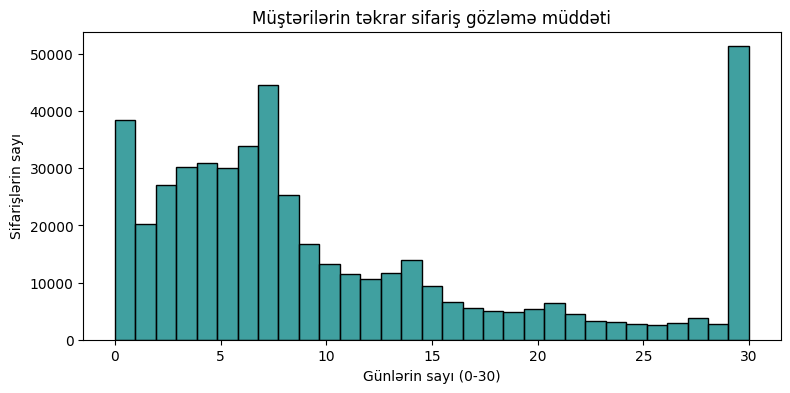

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns
print(orders["days_since_prior_order"].agg(["min", "max"]))
plt.figure(figsize=(9, 4))
sns.histplot(orders['days_since_prior_order'], bins=31, kde=False, color='teal')

plt.title('Müştərilərin təkrar sifariş gözləmə müddəti')
plt.xlabel('Günlərin sayı (0-30)')
plt.ylabel('Sifarişlərin sayı')
plt.show()

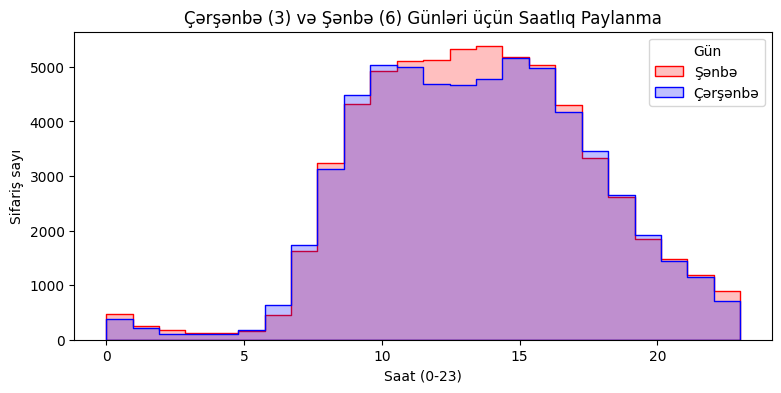

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns
wed_sat = orders[orders['order_dow'].isin([3, 6])]
plt.figure(figsize=(9, 4))
sns.histplot(data=wed_sat, x='order_hour_of_day', hue='order_dow',
             bins=24, kde=False, palette={3: 'blue', 6: 'red'}, element="step")

plt.title('Çərşənbə (3) və Şənbə (6) Günləri üçün Saatlıq Paylanma')
plt.xlabel('Saat (0-23)')
plt.ylabel('Sifariş sayı')
plt.legend(title='Gün', labels=['Şənbə', 'Çərşənbə'])
plt.show()

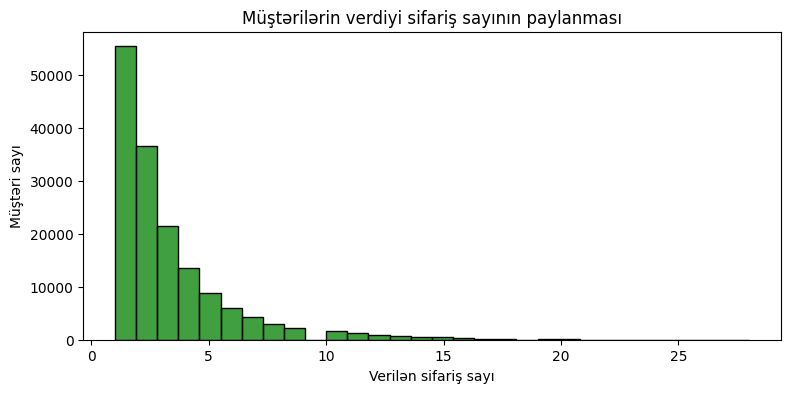

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns
user_order_counts = orders.groupby('user_id')['order_id'].nunique()
plt.figure(figsize=(9, 4))
sns.histplot(user_order_counts, bins=30, kde=False, color='green')

plt.title('Müştərilərin verdiyi sifariş sayının paylanması')
plt.xlabel('Verilən sifariş sayı')
plt.ylabel('Müştəri sayı')
plt.show()

In [61]:
merged_df = order_products.merge(products, on='product_id')
top_20_prdct = merged_df.groupby(['product_id', 'product_name'])['order_id'].count().sort_values(ascending=False).head(20)
print(top_20_prdct)

product_id  product_name            
24852       Banana                      66050
13176       Bag of Organic Bananas      53297
21137       Organic Strawberries        37039
21903       Organic Baby Spinach        33971
47209       Organic Hass Avocado        29773
47766       Organic Avocado             24689
47626       Large Lemon                 21495
16797       Strawberries                20018
26209       Limes                       19690
27845       Organic Whole Milk          19600
27966       Organic Raspberries         19197
22935       Organic Yellow Onion        15898
24964       Organic Garlic              15292
45007       Organic Zucchini            14584
39275       Organic Blueberries         13879
49683       Cucumber Kirby              13675
28204       Organic Fuji Apple          12544
5876        Organic Lemon               12232
8277        Apple Honeycrisp Organic    11993
40706       Organic Grape Tomatoes      11781
Name: order_id, dtype: int64


##Ən çox alınan məshulların siyahısı

In [62]:
reorder_rate = order_products.groupby('product_id')['reordered'].mean().reset_index()
result = reorder_rate.merge(products, on='product_id')
result = result[['product_id', 'product_name', 'reordered']]
result.rename(columns={'reordered': 'reorder_rate'}, inplace=True)
result_sorted = result.sort_values(by='reorder_rate', ascending=False)
print(result_sorted.head(10))


       product_id                     product_name  reorder_rate
28108       30644             Organic French Roast           1.0
7340         8054       Bissli Smokey Wheat Snacks           1.0
28114       30650  Mushroom Lover's Veggie Burgers           1.0
41002       44747      Frozen Organic Blackberries           1.0
40998       44743                   Real Zero Cola           1.0
32921       35897                         Ham Hock           1.0
32861       35834         Bulgarian Organic Yogurt           1.0
2684         2939       Cheddar Crunchin' Crackers           1.0
20357       22209     Temples Earl Gray Strong Tea           1.0
20361       22213    2% Reduced Fat Chocolate Milk           1.0
